In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_groq import ChatGroq
from typing_extensions import TypedDict, Annotated
from dotenv import load_dotenv
load_dotenv()

llm = ChatGroq(
    model="qwen/qwen3.6-27b",
    profile={
        "max_input_tokens":131_000
    }
)

# create a state type
class State(TypedDict):
    messages: Annotated[list, add_messages]

# create node (say chatbot)
def chatbot(state: State)->str:
    return {"messages": [llm.invoke(state["messages"])]}

# create graph builder
graph_builder = StateGraph(State)

# bind with nodes
graph_builder.add_node("Chat_Bot_Node", chatbot)

# craete edges
graph_builder.add_edge(START, "Chat_Bot_Node")
graph_builder.add_edge("Chat_Bot_Node", END)

# compile the graph
graph = graph_builder.compile()

In [ ]:
llm.invoke("test")

In [ ]:
# Display the Graph

from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_png()
    )
)

In [12]:
res = graph.invoke({
    "messages": "hi"
})
res
# res["messages"][-1].content

{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='ec9dfb15-bc84-446c-a92c-dd71e15dac5f'),
  AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User said: "hi"\n   - This is a simple greeting.\n\n2.  **Identify Intent:**\n   - The user is initiating a conversation.\n   - No specific question or task is provided.\n\n3.  **Determine Response Strategy:**\n   - Acknowledge the greeting warmly.\n   - Keep it open-ended to encourage the user to share what they need.\n   - Maintain a friendly and helpful tone.\n\n4.  **Draft Response (Mental):**\n   - "Hi there! How can I help you today?"\n   - "Hello! What\'s on your mind?"\n   - "Hi! I\'m here to help. What can I do for you?"\n\n5.  **Refine Response:**\n   - Keep it concise and natural.\n   - "Hi there! How can I help you today?" works well.\n\n6.  **Final Output Generation:** (matches the refined response)\n   - "Hi there! How can I help you today?"✅\n</thin

In [ ]:
# print(res["messages"][-1].content)
graph

In [ ]:
# Streaming the graph output
for event in graph.stream({"messages": "provide a medium paragraph on 'AIML'"}, stream_mode="updates"):
    print(event)
    for value in event.values():
        print(value["messages"][-1].content)

In [ ]:
# Streaming the graph output
for chunk, meta  in graph.stream({"messages": "provide a medium paragraph on 'AIML'"}, stream_mode="messages"):
    print(chunk.content, flush=True)

# Langgraph with tool (Runnable Binding )

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph.message import add_messages

from langchain.chat_models import init_chat_model
from langchain_core.messages import BaseMessage
from langchain.tools import tool
from langchain_tavily import TavilySearch

from typing_extensions import TypedDict, Annotated
from dotenv import load_dotenv

load_dotenv()

# create llm or agent 
llm = init_chat_model(
    "groq:qwen/qwen3.6-27b",
    profile={
        "max_input_tokens": 262_000
    }
)


@tool
def isPrime_tool(num1:int, num2:int)->bool:
    """
    This Tool validates whether a number (num1) is prime factore of number (num2) or not
    
    Args:
        num1(int): the first number to check whether its a prime or not
        num2(int): second number,whther a num1 is prime factors of num2
    Returns:
        bool: if num2 is prime and factor of num2 then it returns true else false 
    """
    return True

tavily_tool = TavilySearch(max_results=3)

# list of tools
tools = [isPrime_tool, tavily_tool]

# bind the tools
llm_with_tool = llm.bind_tools(tools)


# create s state
class State(TypedDict):
    messages:Annotated[list[BaseMessage], add_messages]

# create Graph builder
graph_builder = StateGraph(State)

graph_builder.add_node("llm_with_tool", llm_with_tool)
graph_builder.add_node("tools", ToolNode(tools))

graph_builder.add_edge(START, "llm_with_tool")
graph_builder.add_edge("llm_with_tool", "tools")
graph_builder.add_edge("llm_with_tool", END)
graph_builder.add_edge("tools", END)
 
# compile the graph
graph = graph_builder.compile()

In [3]:
tavily_tool.invoke("what is the current rate of bmw x4 m in INDIA")

{'query': 'what is the current rate of bmw x4 m in INDIA',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.carwale.com/bmw-cars/x4',
   'title': 'BMW X4 Price - Images, Colors & Reviews',
   'content': 'BMW X4 Price in India starts at Rs. 91.00 Lakh. Check out BMW X4 Colours, Review, Images and X4 Variants On Road Price at Carwale.com.',
   'score': 0.8390101,
   'raw_content': None,
   'id': '644e23-00'},
  {'url': 'https://www.cardekho.com/bmw/x4',
   'title': 'BMW X4 Price, Images, Mileage, Reviews, Specs',
   'content': "Price: It is priced at Rs 96.20 lakh (ex-showroom pan India). Variant: BMW is offering the X4 in a single fully loaded 'M40i' variant. Colours: The X4 M40i is",
   'score': 0.83549726,
   'raw_content': None,
   'id': '022b11-01'},
  {'url': 'https://www.bmw.in/en/index.html',
   'title': 'Explore BMW latest Model in India & Book Test Drive|BMW.in',
   'content': '### BMW 7 SERIES.\n\n## Find your BMW.\n\n### Find a n

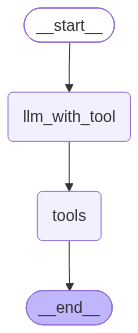

In [2]:
graph